# Ejercicio 2

In [1]:
from sympy import symbols, diff

j, k= symbols('j k', real=True)

f = k**2 - 2*j*k + 2*j**2 + 18*j - 20*k + 201
display(f)

df_dj = diff(f,j)
display(df_dj)

df_dk = diff(f,k)
display(df_dk)

e = 0.000001 
n = 0.05
(pj, pk) = (1, 1)
pz = f.evalf(subs = {j:pj, k:pk})
while True:
    rj = pj-n*df_dj.evalf(subs = {j:pj,k:pk})
    rk = pk-n*df_dk.evalf(subs = {j:pj,k:pk})
    rz = f.evalf(subs = {j:rj, k:rk})
    if(abs(rz - pz) < e):
        break
    pj = rj
    pk = rk
    pz = rz

print("Minimo en (%f,%f) vale %f" % (rj, rk, rz) )

2*j**2 - 2*j*k + 18*j + k**2 - 20*k + 201

4*j - 2*k + 18

-2*j + 2*k - 20

Minimo en (0.997044,10.995217) vale 100.000012


# Ejercicio 3

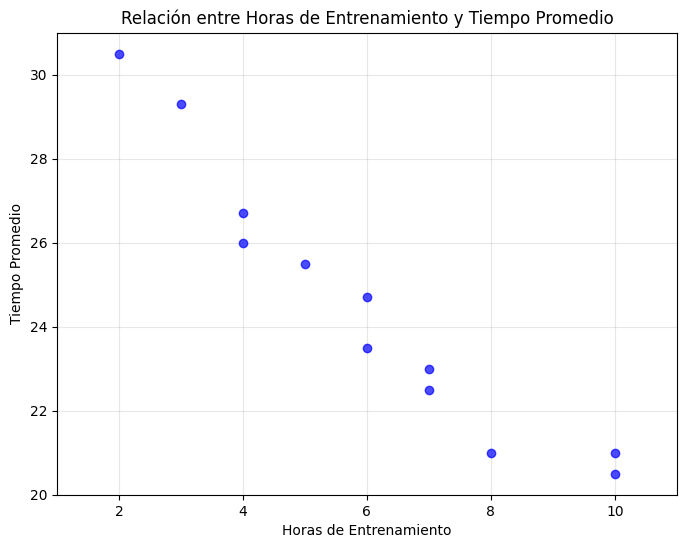

Coeficiente de correlación (Pearson): -0.960


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

horas_entrenamiento = [2, 3, 4, 4, 5, 6, 6, 7, 7, 8, 10, 10]

tiempo_promedio = [30.5, 29.3, 26.7, 26, 25.5, 24.7, 23.5, 23, 22.5, 21, 21, 20.5]

X = np.array(horas_entrenamiento)
Y = np.array(tiempo_promedio)

# Gráfica de dispersión
plt.figure(figsize=(8, 6))
plt.plot(X, Y, 'o', color='blue', alpha=0.7, markersize=6)
plt.title('Relación entre Horas de Entrenamiento y Tiempo Promedio')
plt.xlabel('Horas de Entrenamiento')
plt.ylabel('Tiempo Promedio')
plt.grid(True, alpha=0.3)
plt.xlim(1, 11)
plt.ylim(20, 31)
plt.show()

# Cálculo del coeficiente de correlación
correlacion = np.corrcoef(X, Y)[0, 1]
print(f"Coeficiente de correlación (Pearson): {correlacion:.3f}")

In [3]:
import sys
import os

# Ruta absoluta a la carpeta "Fuentes"
ruta_fuentes = os.path.abspath(os.path.join(os.getcwd(), "..", "Fuentes"))
sys.path.append(ruta_fuentes)

from ClassNeuronaLineal import NeuronaLineal

x_train = X.reshape(-1,1)    # selecciona entradas y formatea a Nx1
y_train = Y.reshape(-1,1)    # selecciona salidas y formatea a Nx1

# entrena neurona lineal y grafica
modelo = NeuronaLineal(alpha=0.01, n_iter=500, cotaE=0.1, draw=0, title=['Horas', 'Tiempo'])
modelo.w_ = -1.1301
modelo.b_ = 31.2102

dato = 6 # horas de estudio dedicadas
print('Quien dedicó %d horas de entrenamiento tardará %d como tiempo promedio' % (dato, modelo.predict([dato])))   # prediccio

Quien dedicó 6 horas de entrenamiento tardará 24 como tiempo promedio


C:\Users\gonza\AppData\Local\Temp\ipykernel_11648\3221875368.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Quien dedicó %d horas de entrenamiento tardará %d como tiempo promedio' % (dato, modelo.predict([dato])))   # prediccio


In [4]:
learning = 0.0005
epochs = 5000
# b0 es la ordenada al origen y b1 la pendiente de la recta de regresion lineal simple
b0, b1 = 0.0, 0.0

rng = np.random.default_rng(42)

for epoch in range(epochs):
    # ACÁ SE DA LO DE LOS MINILOTES, TOMAMOS UNA PERMUTACION RANDOM DE LAS VARAIABLES PARA CALCULAR ERROR
    indicies = rng.permutation(len(X))
    for i in indicies:
        xi = X[i]
        yi = Y[i]
        # Predicción de una variable actual
        y_pred = b0 + b1 * xi
        error = y_pred - yi
        # Actualizacion de ordenada al origen y pendiente
        b0 -= learning * error
        b1 -= learning * error * xi

print ("El b0 es", b0, "y el b1 es", b1)

# Punto de e)
X = 9
predict = b0 + b1 * X
print("Predicción para 9 horas de entrenamiento sin estandarizar:", predict)

El b0 es 31.324525786512535 y el b1 es -1.1442871804743586
Predicción para 9 horas de entrenamiento sin estandarizar: 21.025941162243306


# Ejercicio 4

In [5]:
import pandas as pd

ds_path = "../Datos/CCPP.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,AT,V,AP,RH,PE
0,14.9600,41.7600,1024.0700,73.1700,463.2600
1,25.1800,62.9600,1020.0400,59.0800,444.3700
2,5.1100,39.4000,1012.1600,92.1400,488.5600
3,20.8600,57.3200,1010.2400,76.6400,446.4800
4,10.8200,37.5000,1009.2300,96.6200,473.9000


In [6]:
X = df[["AT"]].values  
T = df["PE"].values

parametros = [
    ("a", -2.00, 500),
    ("b", -2.21, 498),
    ("c", -2.30, 497),
    ("d", -2.22, 496.5),
    ("e", -2.16, 496.91),
]

resultados = []
for nombre, W, b in parametros:
    modelo = NeuronaLineal(alpha=0.01, n_iter=500, cotaE=0.1)
    modelo.w_ = np.array([W], dtype=float)
    modelo.b_ = float(b)
    Y = modelo.predict(X)
    mse = np.mean((T - Y)**2)
    resultados.append((nombre, W, b, mse))
    print(f"{nombre}) W={W}, b={b} -> MSE={mse:.4f}")

resultados.sort(key=lambda t: t[3])
print("\nLos dos combinadores con menor MSE son:")
for r in resultados[:2]:
    print(f"{r[0]}) W={r[1]}, b={r[2]} -> MSE={r[3]:.4f}")

a) W=-2.0, b=500 -> MSE=71.1626
b) W=-2.21, b=498 -> MSE=29.5571
c) W=-2.3, b=497 -> MSE=36.9194
d) W=-2.22, b=496.5 -> MSE=31.7856
e) W=-2.16, b=496.91 -> MSE=29.4485

Los dos combinadores con menor MSE son:
e) W=-2.16, b=496.91 -> MSE=29.4485
b) W=-2.21, b=498 -> MSE=29.5571


# Ejercicio 5

In [17]:
ds_path = "../Datos/automobile-simple.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,make,fuel-type,num-of-doors,body-style,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price,volume,eco-rating
0,alfa-romero,gas,two,convertible,2548,130,111.0000,21,27,13495.0000,528019.9040,33.2975
1,alfa-romero,gas,two,convertible,2548,130,111.0000,21,27,16500.0000,528019.9040,33.2975
2,alfa-romero,gas,two,hatchback,2823,152,154.0000,19,26,16500.0000,587592.6400,30.8983
3,audi,gas,four,sedan,2337,109,102.0000,24,30,13950.0000,634816.9560,42.6978
4,audi,gas,four,sedan,2824,136,115.0000,18,22,17450.0000,636734.8320,27.9975


In [20]:
print('Antes:\n',df.isnull().sum(), '\n')

df['price'].fillna(df['price'].mean(), inplace=True)

print('Despues:\n',df.isnull().sum(), '\n')

Antes:
 make            0
fuel-type       0
num-of-doors    2
body-style      0
curb-weight     0
engine-size     0
horsepower      2
city-mpg        0
highway-mpg     0
price           4
volume          0
eco-rating      0
dtype: int64 

Despues:
 make            0
fuel-type       0
num-of-doors    2
body-style      0
curb-weight     0
engine-size     0
horsepower      2
city-mpg        0
highway-mpg     0
price           0
volume          0
eco-rating      0
dtype: int64 



C:\Users\gonza\AppData\Local\Temp\ipykernel_11648\1515603588.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].mean(), inplace=True)


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
def train_and_get_error(X, y, alpha=0.001, n_iter=2000):
    neurona = NeuronaLineal(alpha=alpha, n_iter=n_iter, draw=0)
    neurona.fit(X, y)
    y_pred = neurona.predict(X)
    mse = np.mean((y_pred - y) ** 2)
    return neurona, mse

# Sin normalizar
X = df[['engine-size']].to_numpy(dtype=np.float64)
y = df['price'].to_numpy(dtype=np.float64).reshape(-1, 1).ravel()
neurona, mse = train_and_get_error(X, y, alpha=1e-6, n_iter=2000)
print(f"Neurona entrenada: W={neurona.w_[0]}, b={neurona.b_} -> MSE={mse:.4f}")

scaler = StandardScaler()
X = scaler.fit_transform(df[['engine-size']].to_numpy(dtype=float))
y = scaler.fit_transform(df['price'].to_numpy(dtype=float).reshape(-1, 1)).ravel()
neurona, mse = train_and_get_error(X, y)
print(f"Neurona entrenada: W={neurona.w_[0]}, b={neurona.b_} -> MSE={mse:.4f}")

scaler = MinMaxScaler()
X = scaler.fit_transform(df[['engine-size']].to_numpy(dtype=float))
y = scaler.fit_transform(df['price'].to_numpy(dtype=float).reshape(-1, 1)).ravel()
neurona, mse = train_and_get_error(X, y)
print(f"Neurona entrenada: W={neurona.w_[0]}, b={neurona.b_} -> MSE={mse:.4f}")

Neurona entrenada: W=106.70907658587046, b=-269.22354560219475 -> MSE=21299319.2034
Neurona entrenada: W=0.8587776860659633, b=-0.0044190623579609045 -> MSE=0.2574
Neurona entrenada: W=1.0661560223417461, b=-0.06536692493220207 -> MSE=0.0098


# Ejercicio 6

### Con bias

In [10]:
from sklearn.metrics import mean_squared_error

# Entradas (X) → combinaciones binarias de 3 bits
X = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
])

# Salidas (y) → su valor decimal
y = np.array([0,1,2,3,4,5,6,7])

neurona_bias = NeuronaLineal(alpha=0.1, n_iter=2000, cotaE=1e-10, random_state=1)
neurona_bias.fit(X, y)
y_pred = neurona_bias.predict(X)

print("Pesos (con bias):", neurona_bias.w_)
print("Bias:", neurona_bias.b_)
print("Errores:", len(neurona_bias.errors_))
print("MSE:", mean_squared_error(y, y_pred))
print("Exactitud entera:","Si" if np.all(np.rint(y_pred).astype(int) == y) else "No")
print(y_pred)

Pesos (con bias): [3.99999469 1.99999445 0.99999441]
Bias: 1.1865133568081707e-05
Errores: 104
MSE: 3.581417835805094e-11
Exactitud entera: Si
[1.18651336e-05 1.00000628e+00 2.00000632e+00 3.00000073e+00
 4.00000655e+00 5.00000097e+00 6.00000100e+00 6.99999542e+00]


### Sin bias

In [11]:
rgen = np.random.RandomState(None)

# self.w_ = rgen.normal(loc=0.0, scale=0.01,size=1 + X.shape[1])

w_ = rgen.uniform(-0.5, 0.5, size= X.shape[1]) 
b_ = 0
errors_ = []
ErrorAnt = 0
ErrorAct = 1

i = 0
while ((i<2000) and (np.abs(ErrorAnt- ErrorAct) > 1e-10)):
    ErrorAnt = ErrorAct
    ErrorAct = 0
    for xi, target in zip(X, y):
        
        errorXi = (target - np.dot(xi, w_))
        update = 0.1 * errorXi
        w_ += update * xi
        
        ErrorAct += errorXi**2
        
    errors_.append(ErrorAct)
    
    i = i + 1

neurona_no_bias = NeuronaLineal(alpha=0.1, n_iter=2000, cotaE=1e-10)
neurona_no_bias.w_ = w_
neurona_no_bias.b_ = b_
neurona_no_bias.errors_ = errors_

y_pred = neurona_no_bias.predict(X)

print("Pesos (sin bias):", neurona_no_bias.w_)
print("Bias:", neurona_no_bias.b_)
print("Errores:", len(neurona_no_bias.errors_))
print("MSE:", mean_squared_error(y, y_pred))
print("Exactitud entera:","Si" if np.all(np.rint(y_pred).astype(int) == y) else "No")
print(y_pred)

Pesos (sin bias): [3.99999494 1.99999984 1.00000554]
Bias: 0
Errores: 59
MSE: 1.4121166162242152e-11
Exactitud entera: Si
[0.         1.00000554 1.99999984 3.00000538 3.99999494 5.00000048
 5.99999477 7.00000032]


# Ejercicio 8

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from ClassNeuronaGral import NeuronaGradiente
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

df = pd.read_csv("../Datos/semillas.csv")
scalers = [StandardScaler() for i in range(len(df.columns)-1)]
for col, scaler in zip(df.columns[:-1], scalers):
    df[col] = scaler.fit_transform(df[[col]])

X = df[df.columns[:-1]].to_numpy(dtype=float)
labelizer = LabelEncoder()
y_raw = labelizer.fit_transform(df[df.columns[-1]])

In [13]:
def preparar_labels(fun, y_raw):
    if fun == "sigmoid":
        y = np.where(y_raw == 2, 1, 0)   # 0/1
        costo = "EC_binaria"
    elif fun == "tanh":
        y = np.where(y_raw == 2, 1, -1)  # -1/+1
        costo = "EC"
    else:
        raise ValueError("fun debe ser 'sigmoid' o 'tanh'")
    return y, costo

def correr_experimentos(fun):
    resultados = []
    alphas = np.arange(0.04, 0.84, 0.04)
    y, costo = preparar_labels(fun, y_raw)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.6, stratify=y, random_state=42
    )
    for alpha in alphas:

        model = NeuronaGradiente(alpha=alpha, n_iter=20, cotaE=1e-8, FUN=fun, random_state=42)
        model.fit(X_train, y_train)
        # métricas
        errores = model.errors_
        accs = model.accuracy_
        total_iters = len(errores)
        try:
            iter_100 = next(i for i,a in enumerate(accs) if a==1.0)
        except StopIteration:
            iter_100 = None
        test_acc = model.accuracy(X_test, y_test)
        resultados.append({
            "alpha": alpha,
            "iters": total_iters,
            "iter_100": iter_100,
            "final_acc_train": accs[-1],
            "final_acc_test": test_acc,
            "errors": errores,
            "accs": accs
        })
    return resultados
print("Calculando sigmoide")
res_sig = correr_experimentos("sigmoid")
print("Calculando tanh")
res_tanh = correr_experimentos("tanh")

Calculando sigmoide
Calculando tanh


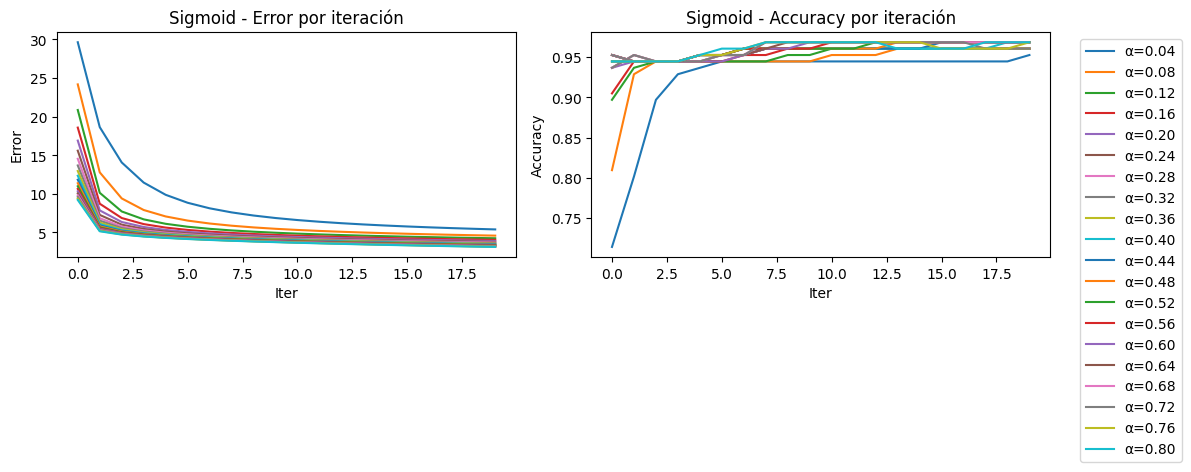

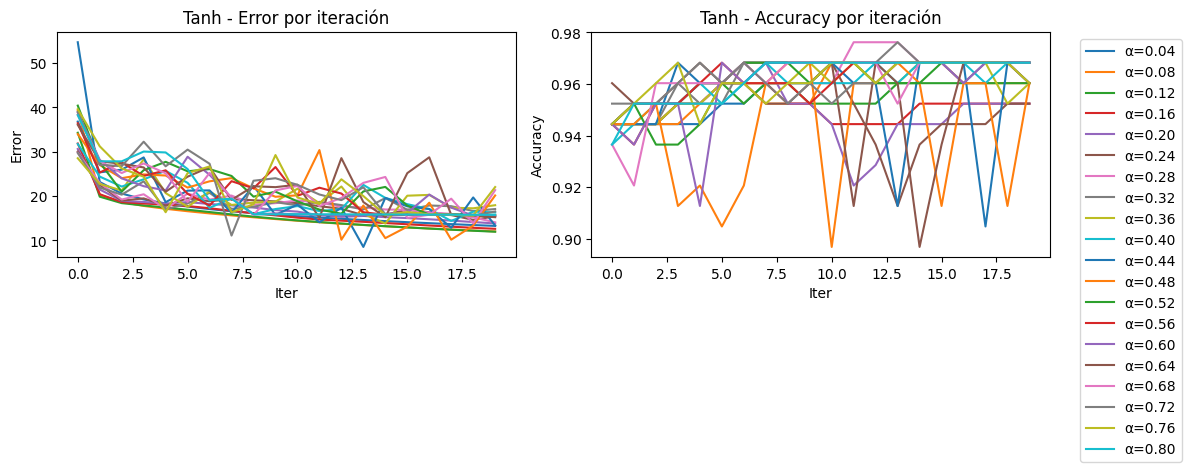

In [14]:
def plot_curvas(res, titulo):
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    for r in res:
        axes[0].plot(r["errors"], label=f"α={r['alpha']:.2f}")
        axes[1].plot(r["accs"], label=f"α={r['alpha']:.2f}")
    axes[0].set_title(f"{titulo} - Error por iteración"); axes[0].set_xlabel("Iter"); axes[0].set_ylabel("Error")
    axes[1].set_title(f"{titulo} - Accuracy por iteración"); axes[1].set_xlabel("Iter"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout(); plt.show()

plot_curvas(res_sig, "Sigmoid")
plot_curvas(res_tanh, "Tanh")

# Ejercicio 9

In [15]:
ds_path = "../Datos/Vinos.csv"

try:
    df = pd.read_csv(ds_path, delimiter= ';')
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315,Proline
0,1,14.2300,1.7100,2.4300,15.6000,127,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065
1,1,13.2000,1.7800,2.1400,11.2000,100,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050
2,1,13.1600,2.3600,2.6700,18.6000,101,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185
3,1,14.3700,1.9500,2.5000,16.8000,113,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,1480
4,1,13.2400,2.5900,2.8700,21.0000,118,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735
